In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [20]:
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


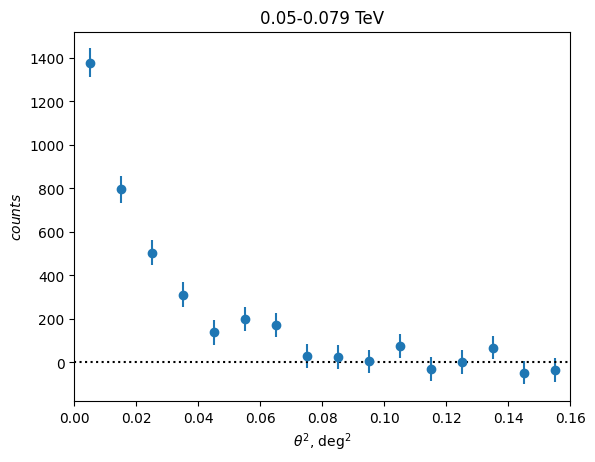

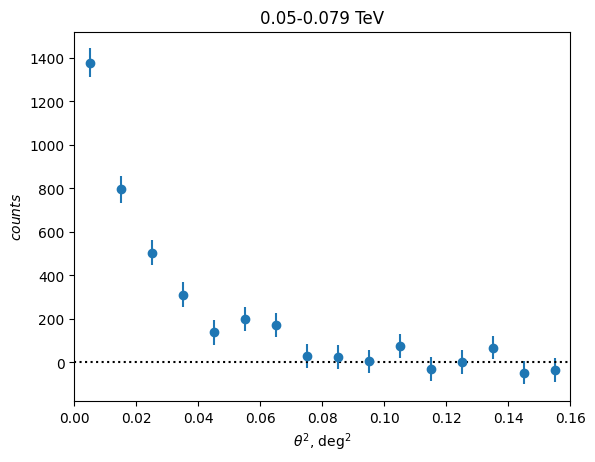

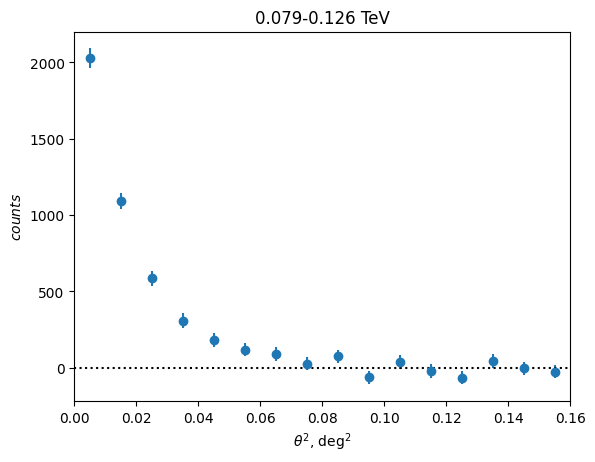

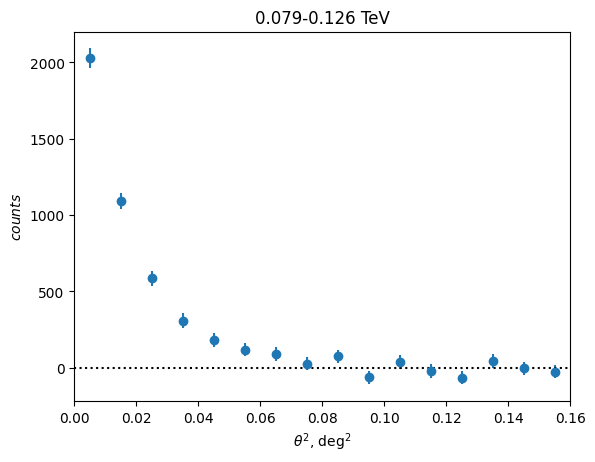

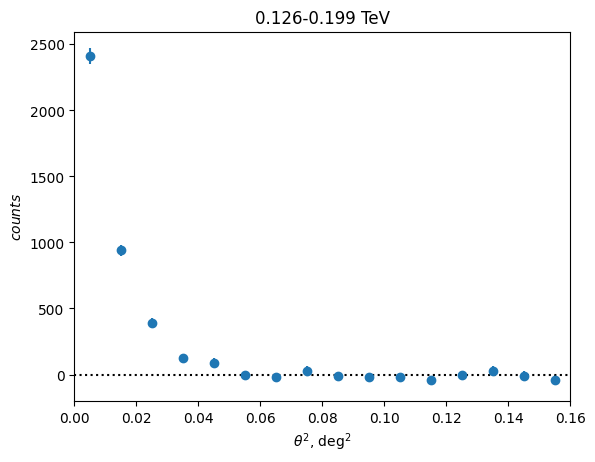

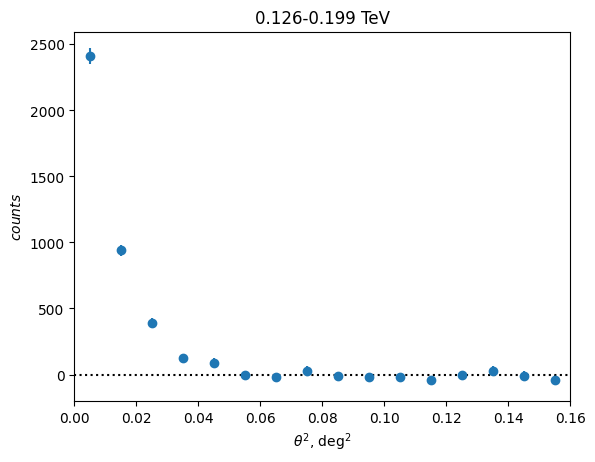

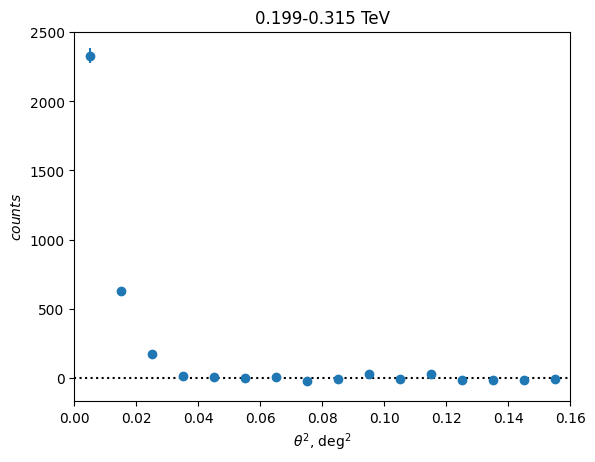

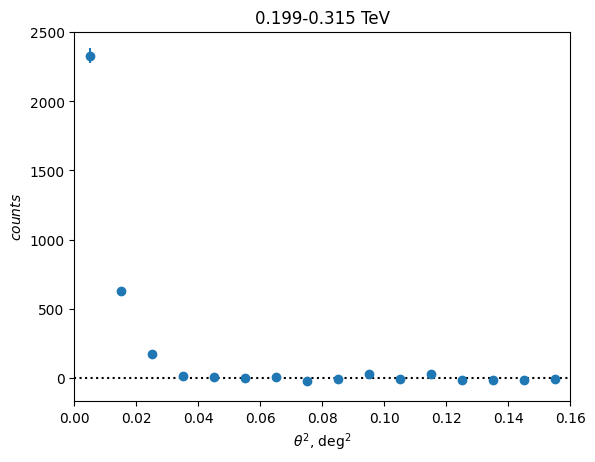

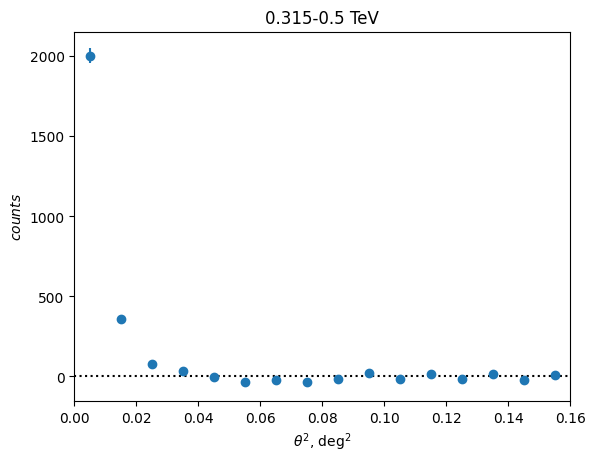

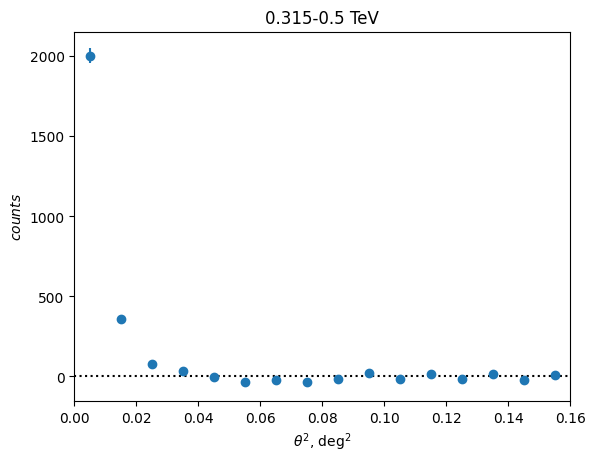

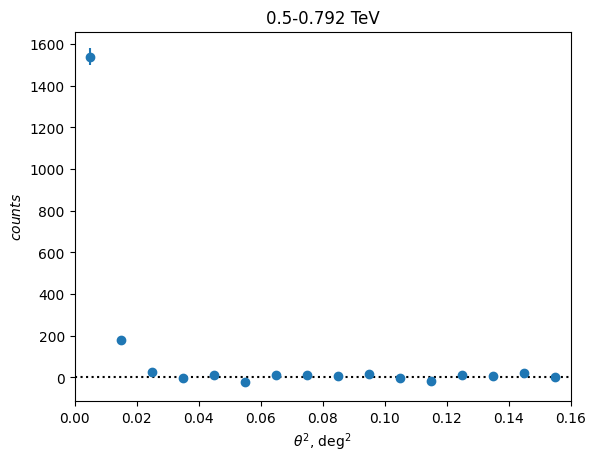

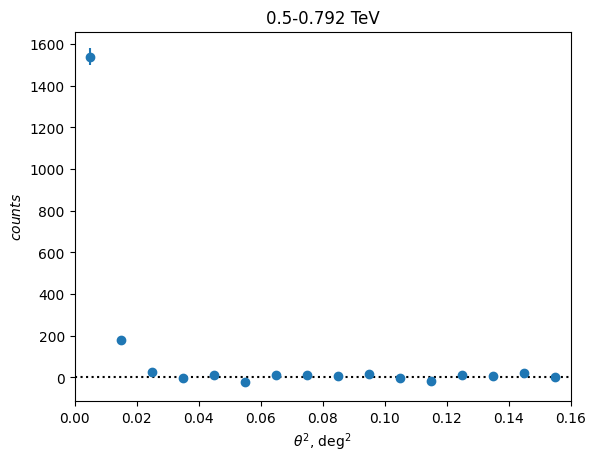

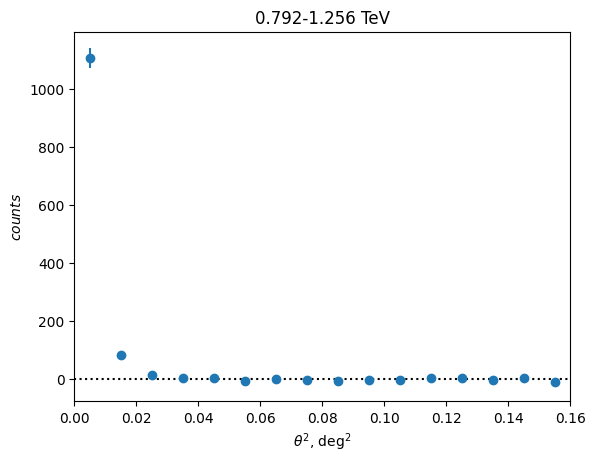

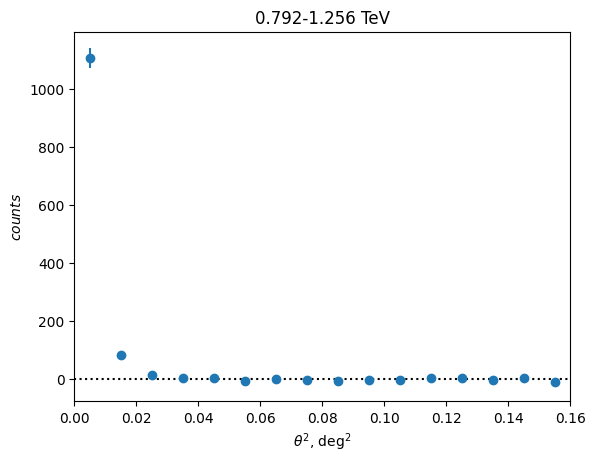

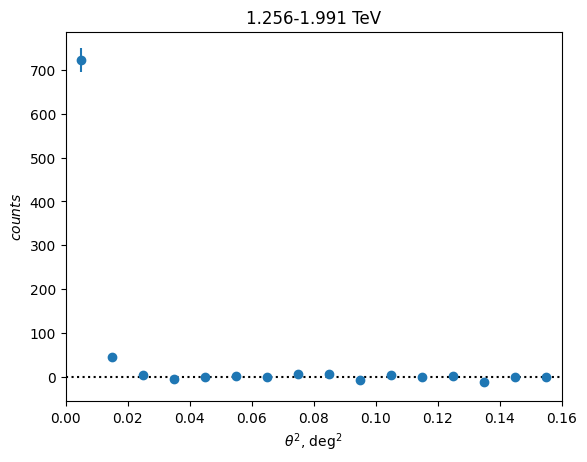

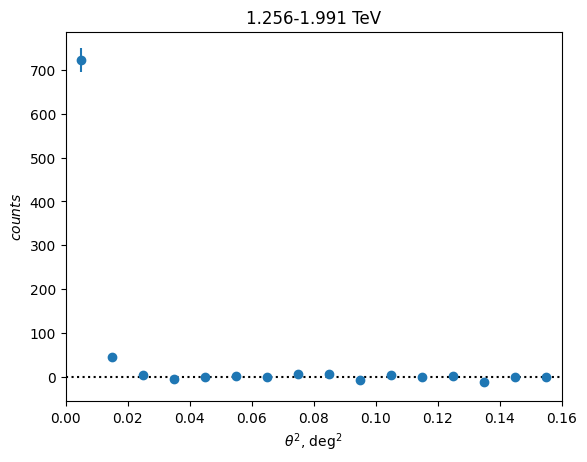

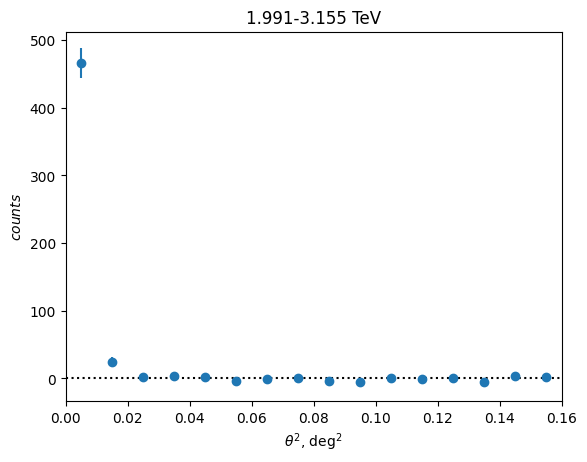

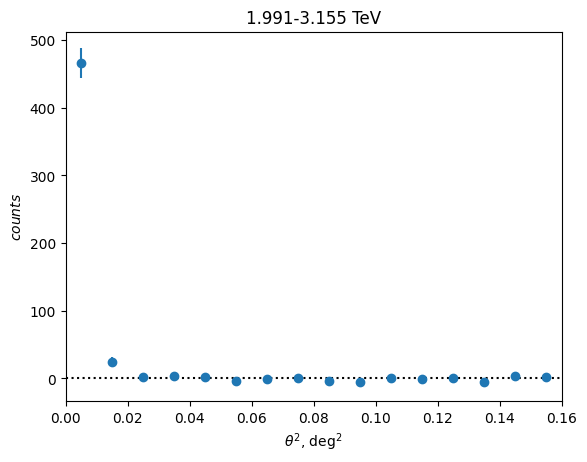

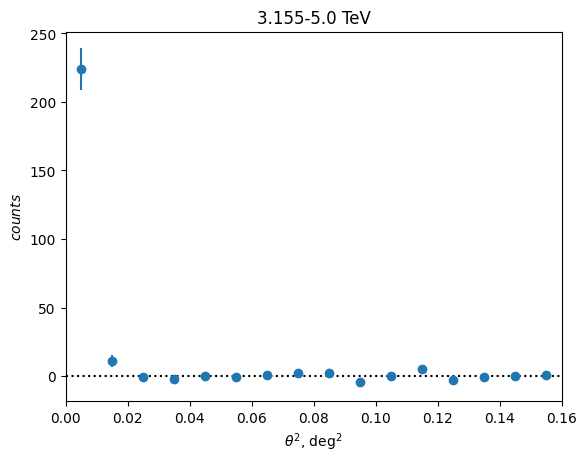

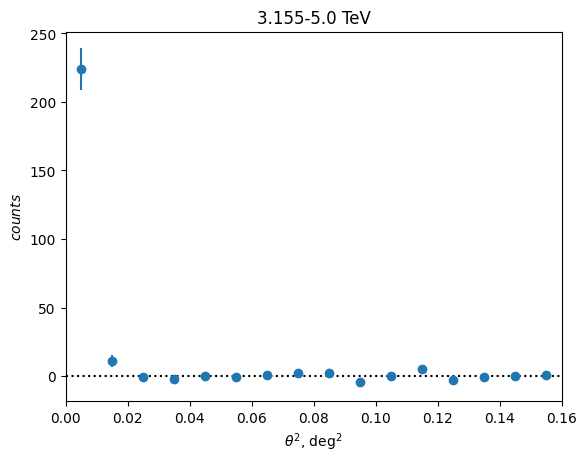

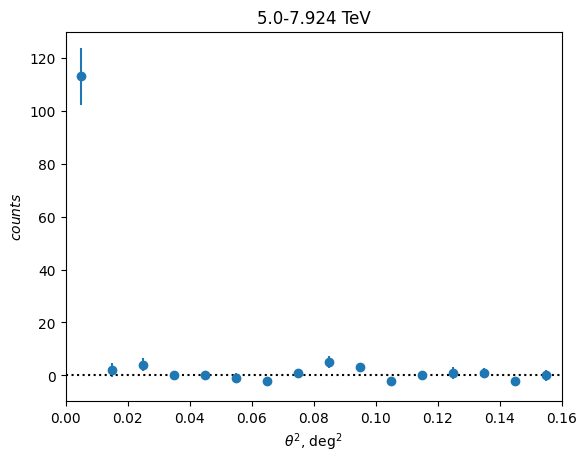

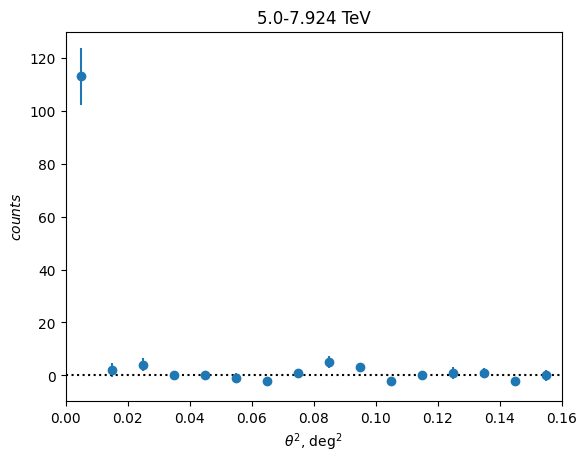

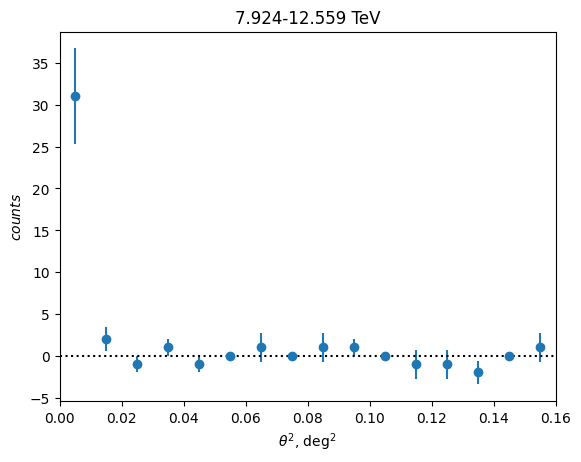

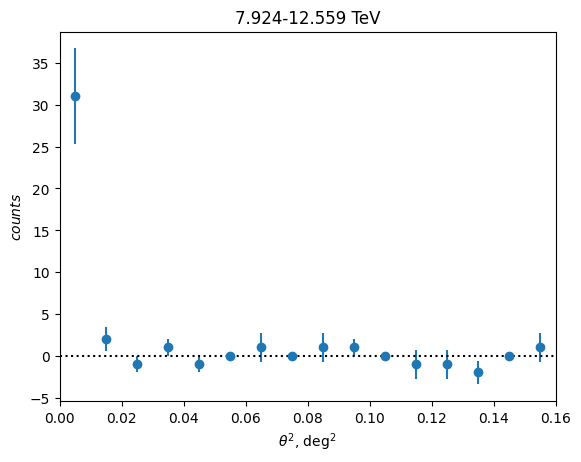

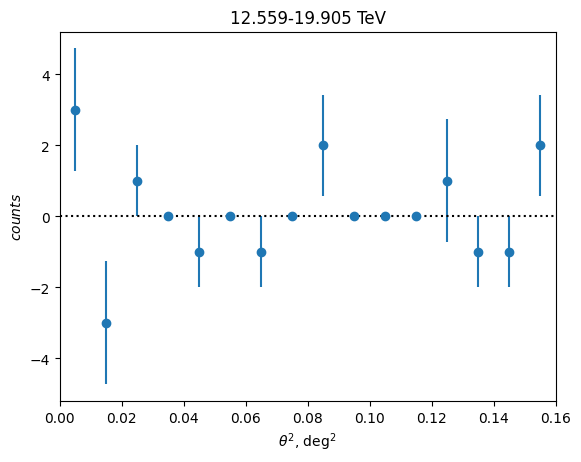

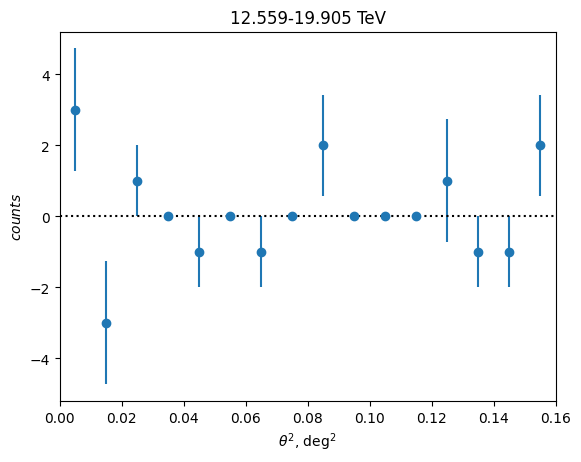

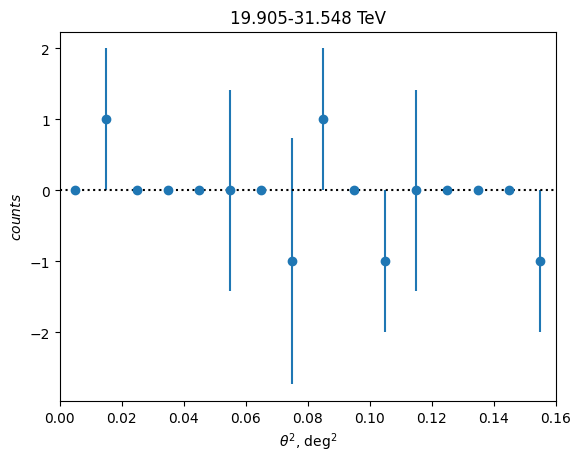

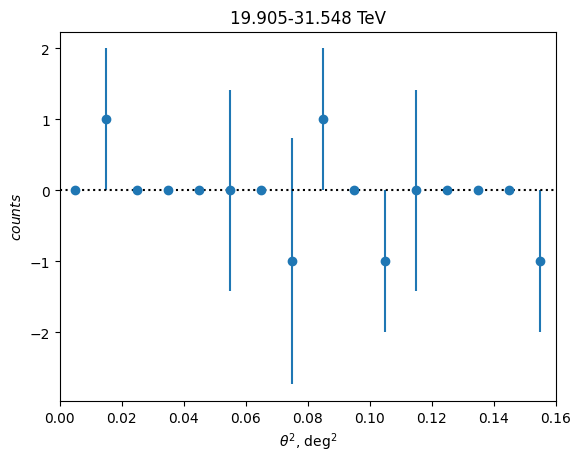

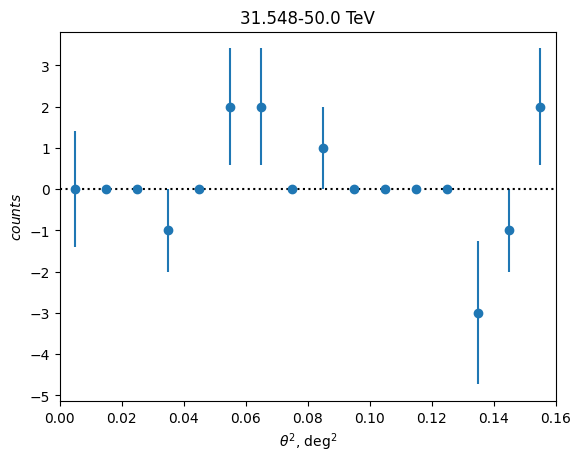

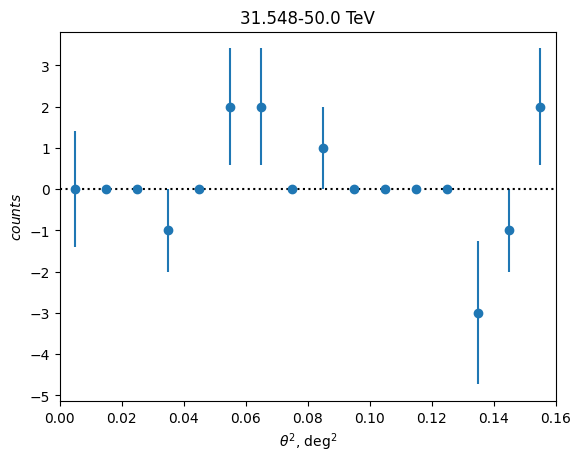

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)


for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
psf_hbu = irf["psf"]
print(psf_hbu)
print(psf_hbu.info())
print(psf_hbu.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

converged at 
61
2.7497999280671213
converged at 
19
2.915449245106476
converged at 
12
2.9576652352644146
converged at 
10
3.101817609329597


/tmp/ipykernel_967/1889454127.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


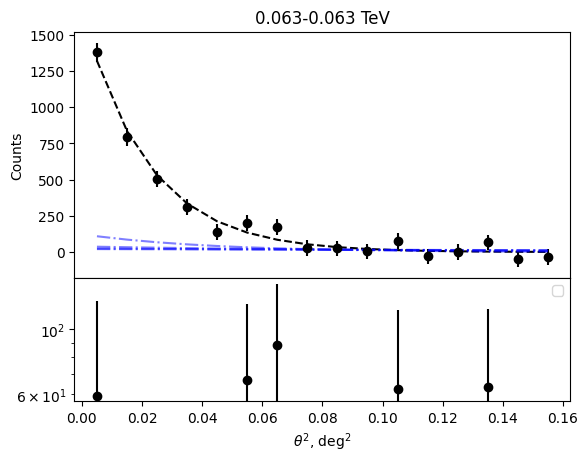

converged at 
90
2.743700781128606
converged at 
21
2.7655527550793515
converged at 
12
2.711057684852456
converged at 
10
3.122476581166426


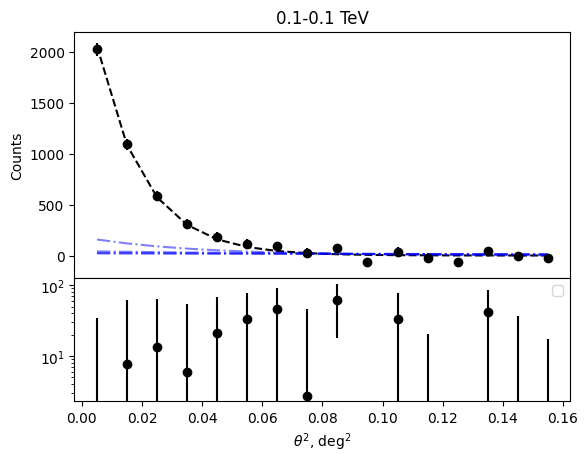

converged at 
18
2.8409078627893365
converged at 
6
3.3107075245315123
converged at 
4
3.5076529195675725
converged at 
3
3.160139428543843


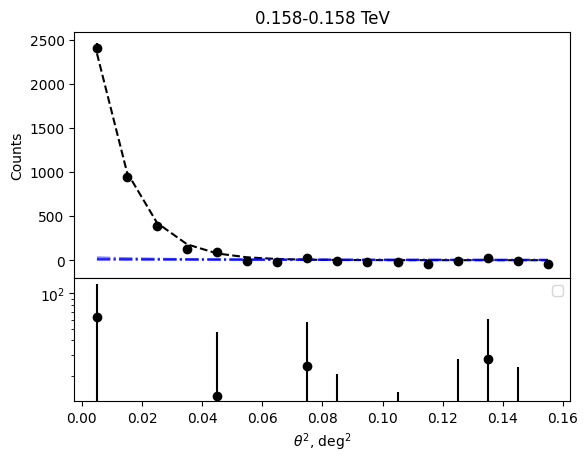

converged at 
9
2.789253305809474
converged at 
4
3.3094337435417636
converged at 
3
3.5805138693238767
converged at 
2
2.7213507117605893


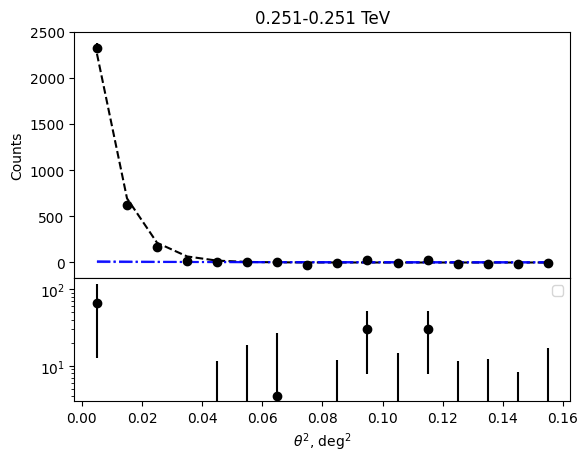

converged at 
7
2.9571583548739966
converged at 
2
3.074458048157865
converged at 
2
4.724276652758668
converged at 
1
2.9847043229341637


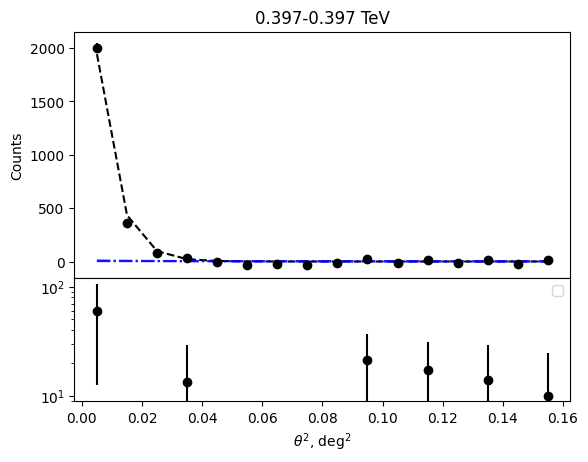

converged at 
4
3.2950496458806953
converged at 
2
2.801994399861748
converged at 
2
3.1885574211586203
converged at 
2
3.550261056533131


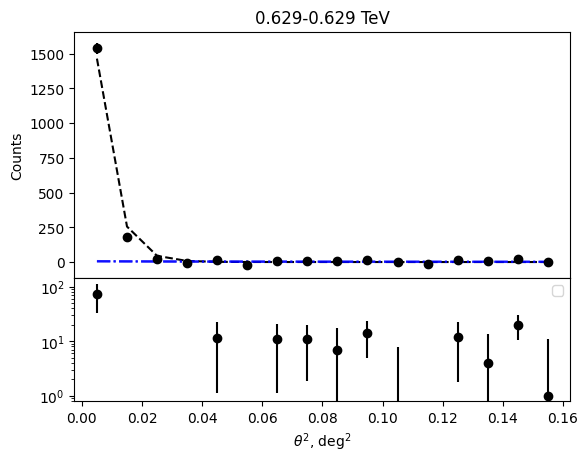

converged at 
3
3.1339314072481486
converged at 
1
3.444598681169701
converged at 
1
5.384448803112335
converged at 
1
6.652000241992937


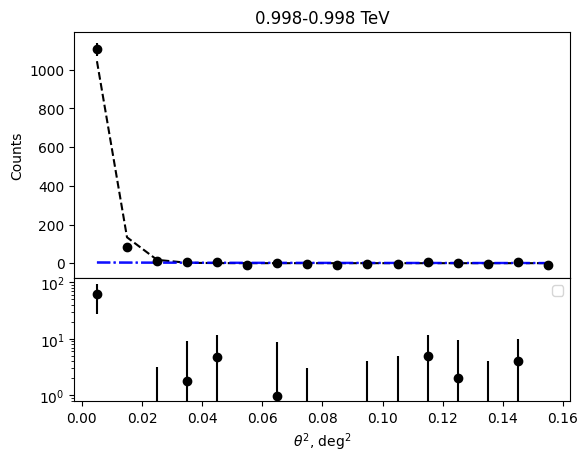

converged at 
2
3.4644628114650757
converged at 
1
5.040510841563638
converged at 
1
8.184899861981343
converged at 
1
10.410717987176987


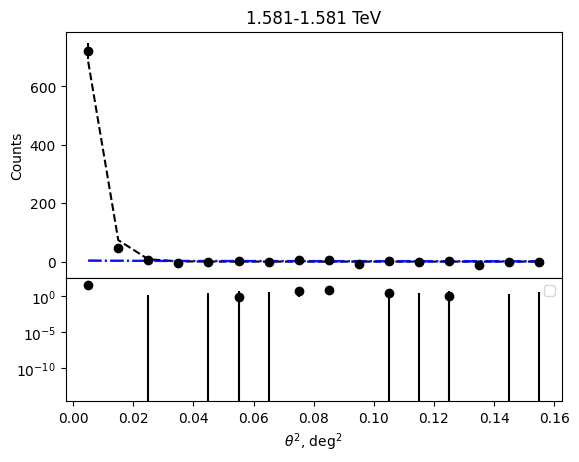

converged at 
2
2.940239613675665
converged at 
1
6.234903499205075
converged at 
1
11.096472864069582
converged at 
1
14.444729172228481


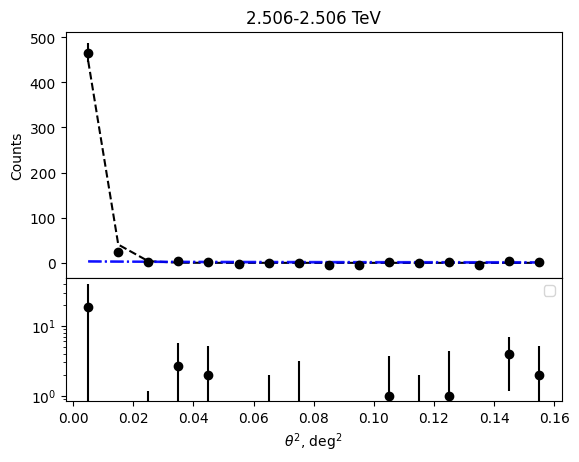

converged at 
1
3.391738736978283
converged at 
0
3.152577560641923
converged at 
0
5.17044678219704
converged at 
0
6.508901309835913


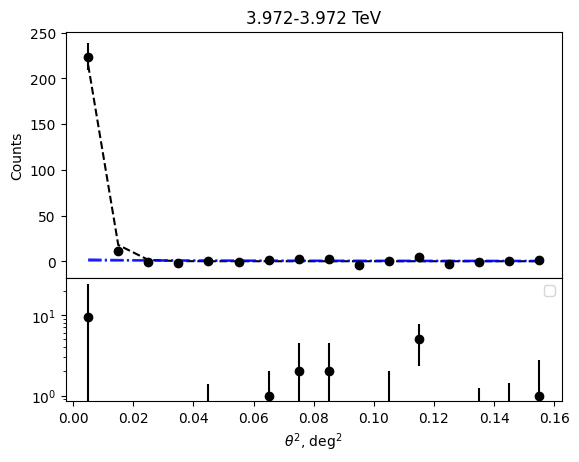

converged at 
2
3.888393091707897
converged at 
1
11.830611719238007
converged at 
0
2.9356932614943183
converged at 
0
4.244716979052821


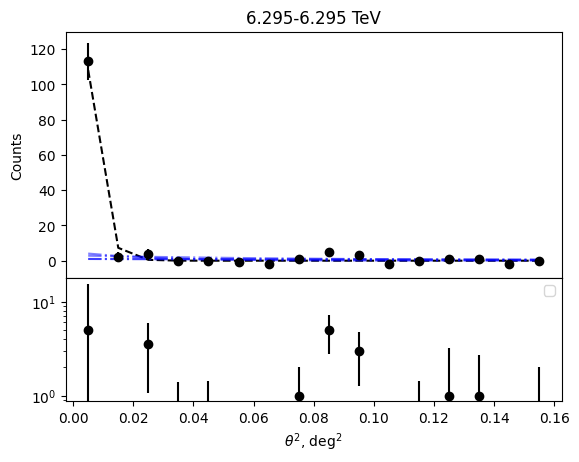

/tmp/ipykernel_967/1889454127.py:28: RuntimeWarning: divide by zero encountered in divide
  chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
/tmp/ipykernel_967/1889454127.py:76: RuntimeWarning: divide by zero encountered in divide
  chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
/tmp/ipykernel_967/1889454127.py:78: RuntimeWarning: invalid value encountered in scalar subtract
  delta_chi2 = chi2_ext - chi2_noext


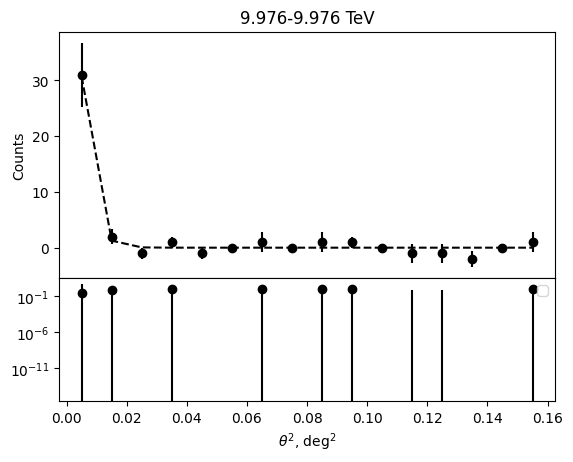

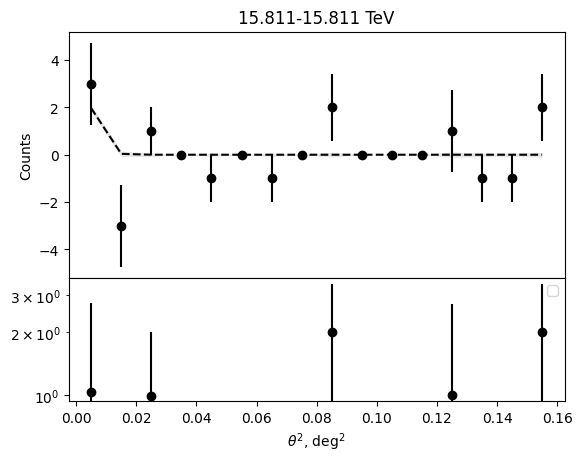

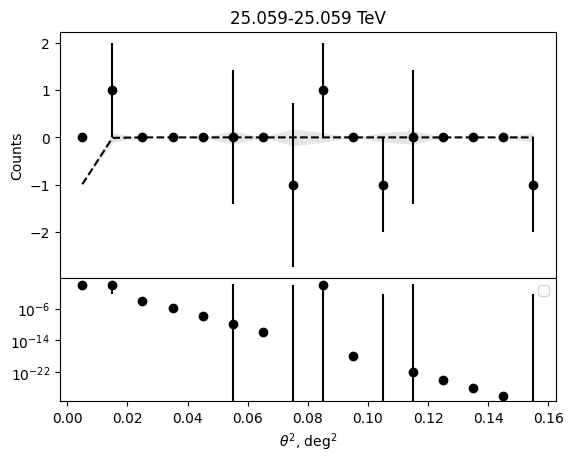

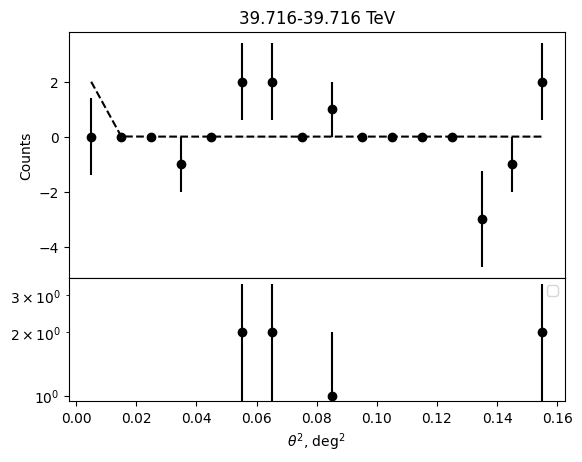

In [22]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.linspace(1, 1000, 500)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # First i renormalize the PSF model to fit best the blazar
    # Then i add a extended em component (gaussian) with different parameters.
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the error
    psf_component_err = ct_err*sum(psf_component)/sum(ct)
    # rescaling the psf component to match total counts of the data
    psf_component *= sum(ct)/sum(psf_component)
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')
    
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            # here i renormalize the point source taking away te extended emission counts.
            no_ext_renormaliz = 1 - np.sum(ct_ext)/np.sum(psf_component)
            ct_ext_plus_src = ct_ext+psf_component*no_ext_renormaliz
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
                              
            delta_chi2 = chi2_ext - chi2_noext
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/(np.sum(psf_component) + np.sum(ct_ext))
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    axs[0].set_ylabel('Counts')
    plt.legend()
    plt.yscale("log")
    plt.show()

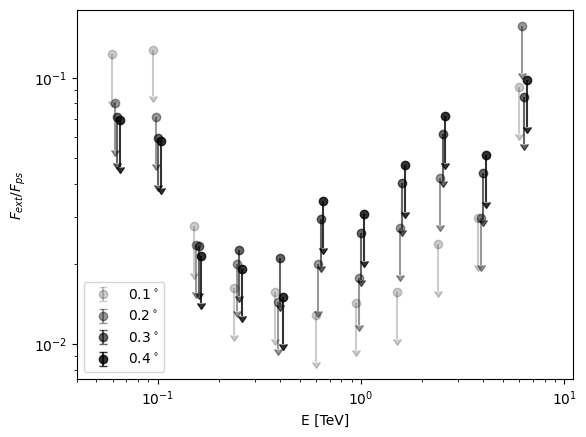

In [18]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)

plt.legend()